In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions 

In [2]:
dataset = pd.read_csv(r"C:\Users\user\Documents\jnotebook\data\Social_Network_Ads.csv")

In [3]:
dataset.head(4)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0


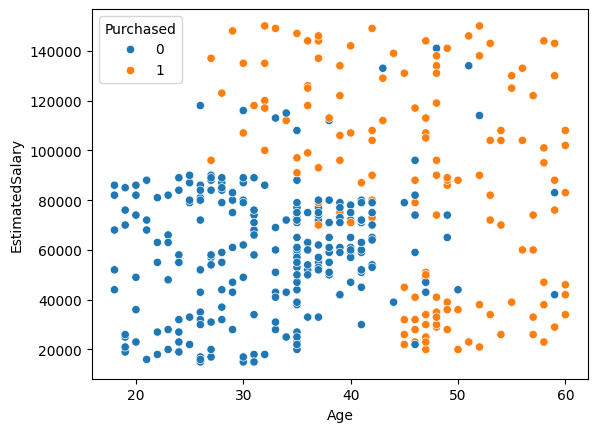

In [4]:
sns.scatterplot(x="Age", y="EstimatedSalary", data=dataset, hue="Purchased")
plt.show()

In [5]:
dataset.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [6]:
x = dataset.iloc[:,:-1]
y = dataset["Purchased"]

In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
ss = StandardScaler()

In [9]:
ss.fit(x)

,copy,True
,with_mean,True
,with_std,True


In [10]:
x = pd.DataFrame(ss.transform(x), columns=x.columns)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=2, test_size=0.2)

In [13]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree Classifier used "GINI" index for tree splitting by default...to use "ENTROPY" index we need to change the criterion field

In [14]:
dtc = DecisionTreeClassifier()

In [15]:
dtc.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
dtc.score(x_test, y_test) * 100

85.0

In [17]:
dtc.predict([[35, 20000]])

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


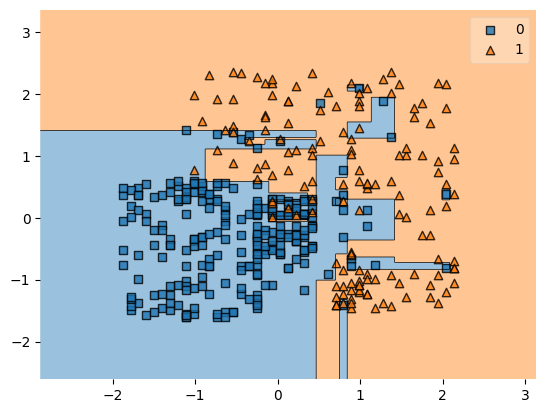

In [18]:
plot_decision_regions(x.to_numpy(), y.to_numpy(), clf=dtc)
plt.show()

# Draw Dicision Tree(Root Node, Sub Nodes)

In [19]:
from sklearn.tree import plot_tree

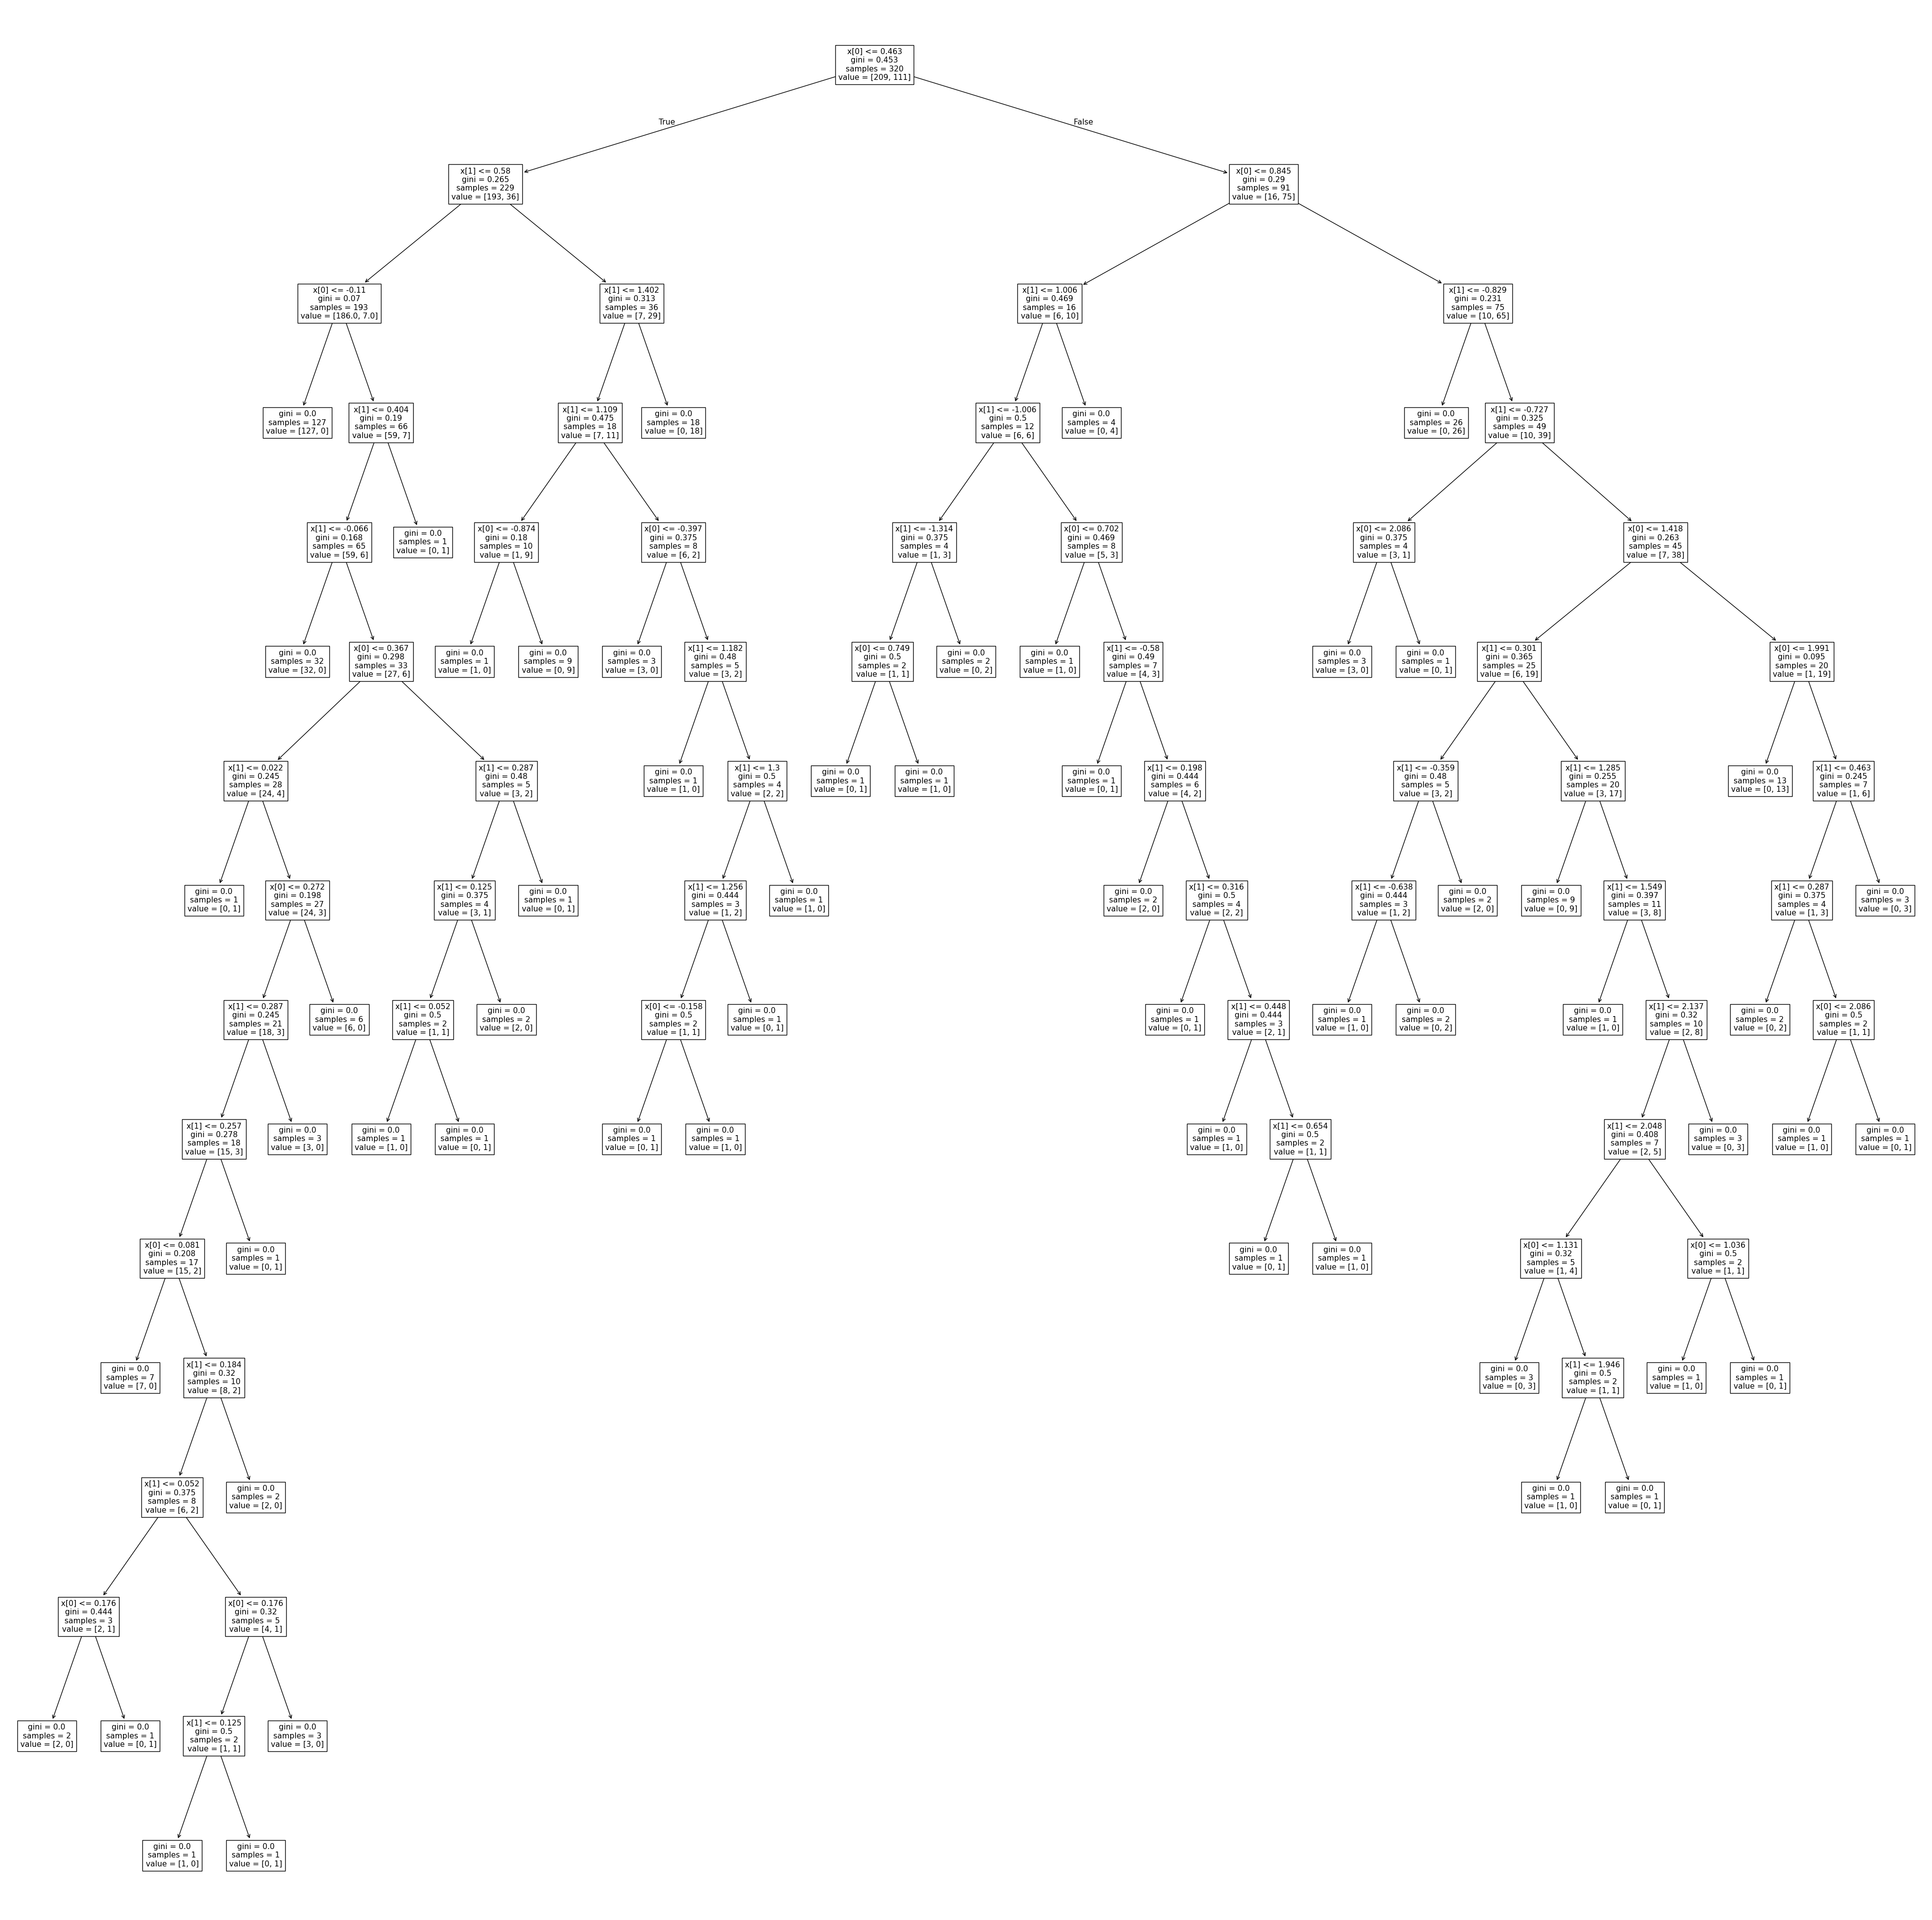

In [20]:
plt.figure(figsize=(50,50))
plot_tree(dtc)
# plt.savefig("demo.jpg")
plt.show()

# Using ENTROPY index

In [21]:
dtce = DecisionTreeClassifier(criterion='entropy')

In [22]:
dtce.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
dtce.score(x_test, y_test) * 100

85.0

In [24]:
dtce.predict([[35, 20000]])

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

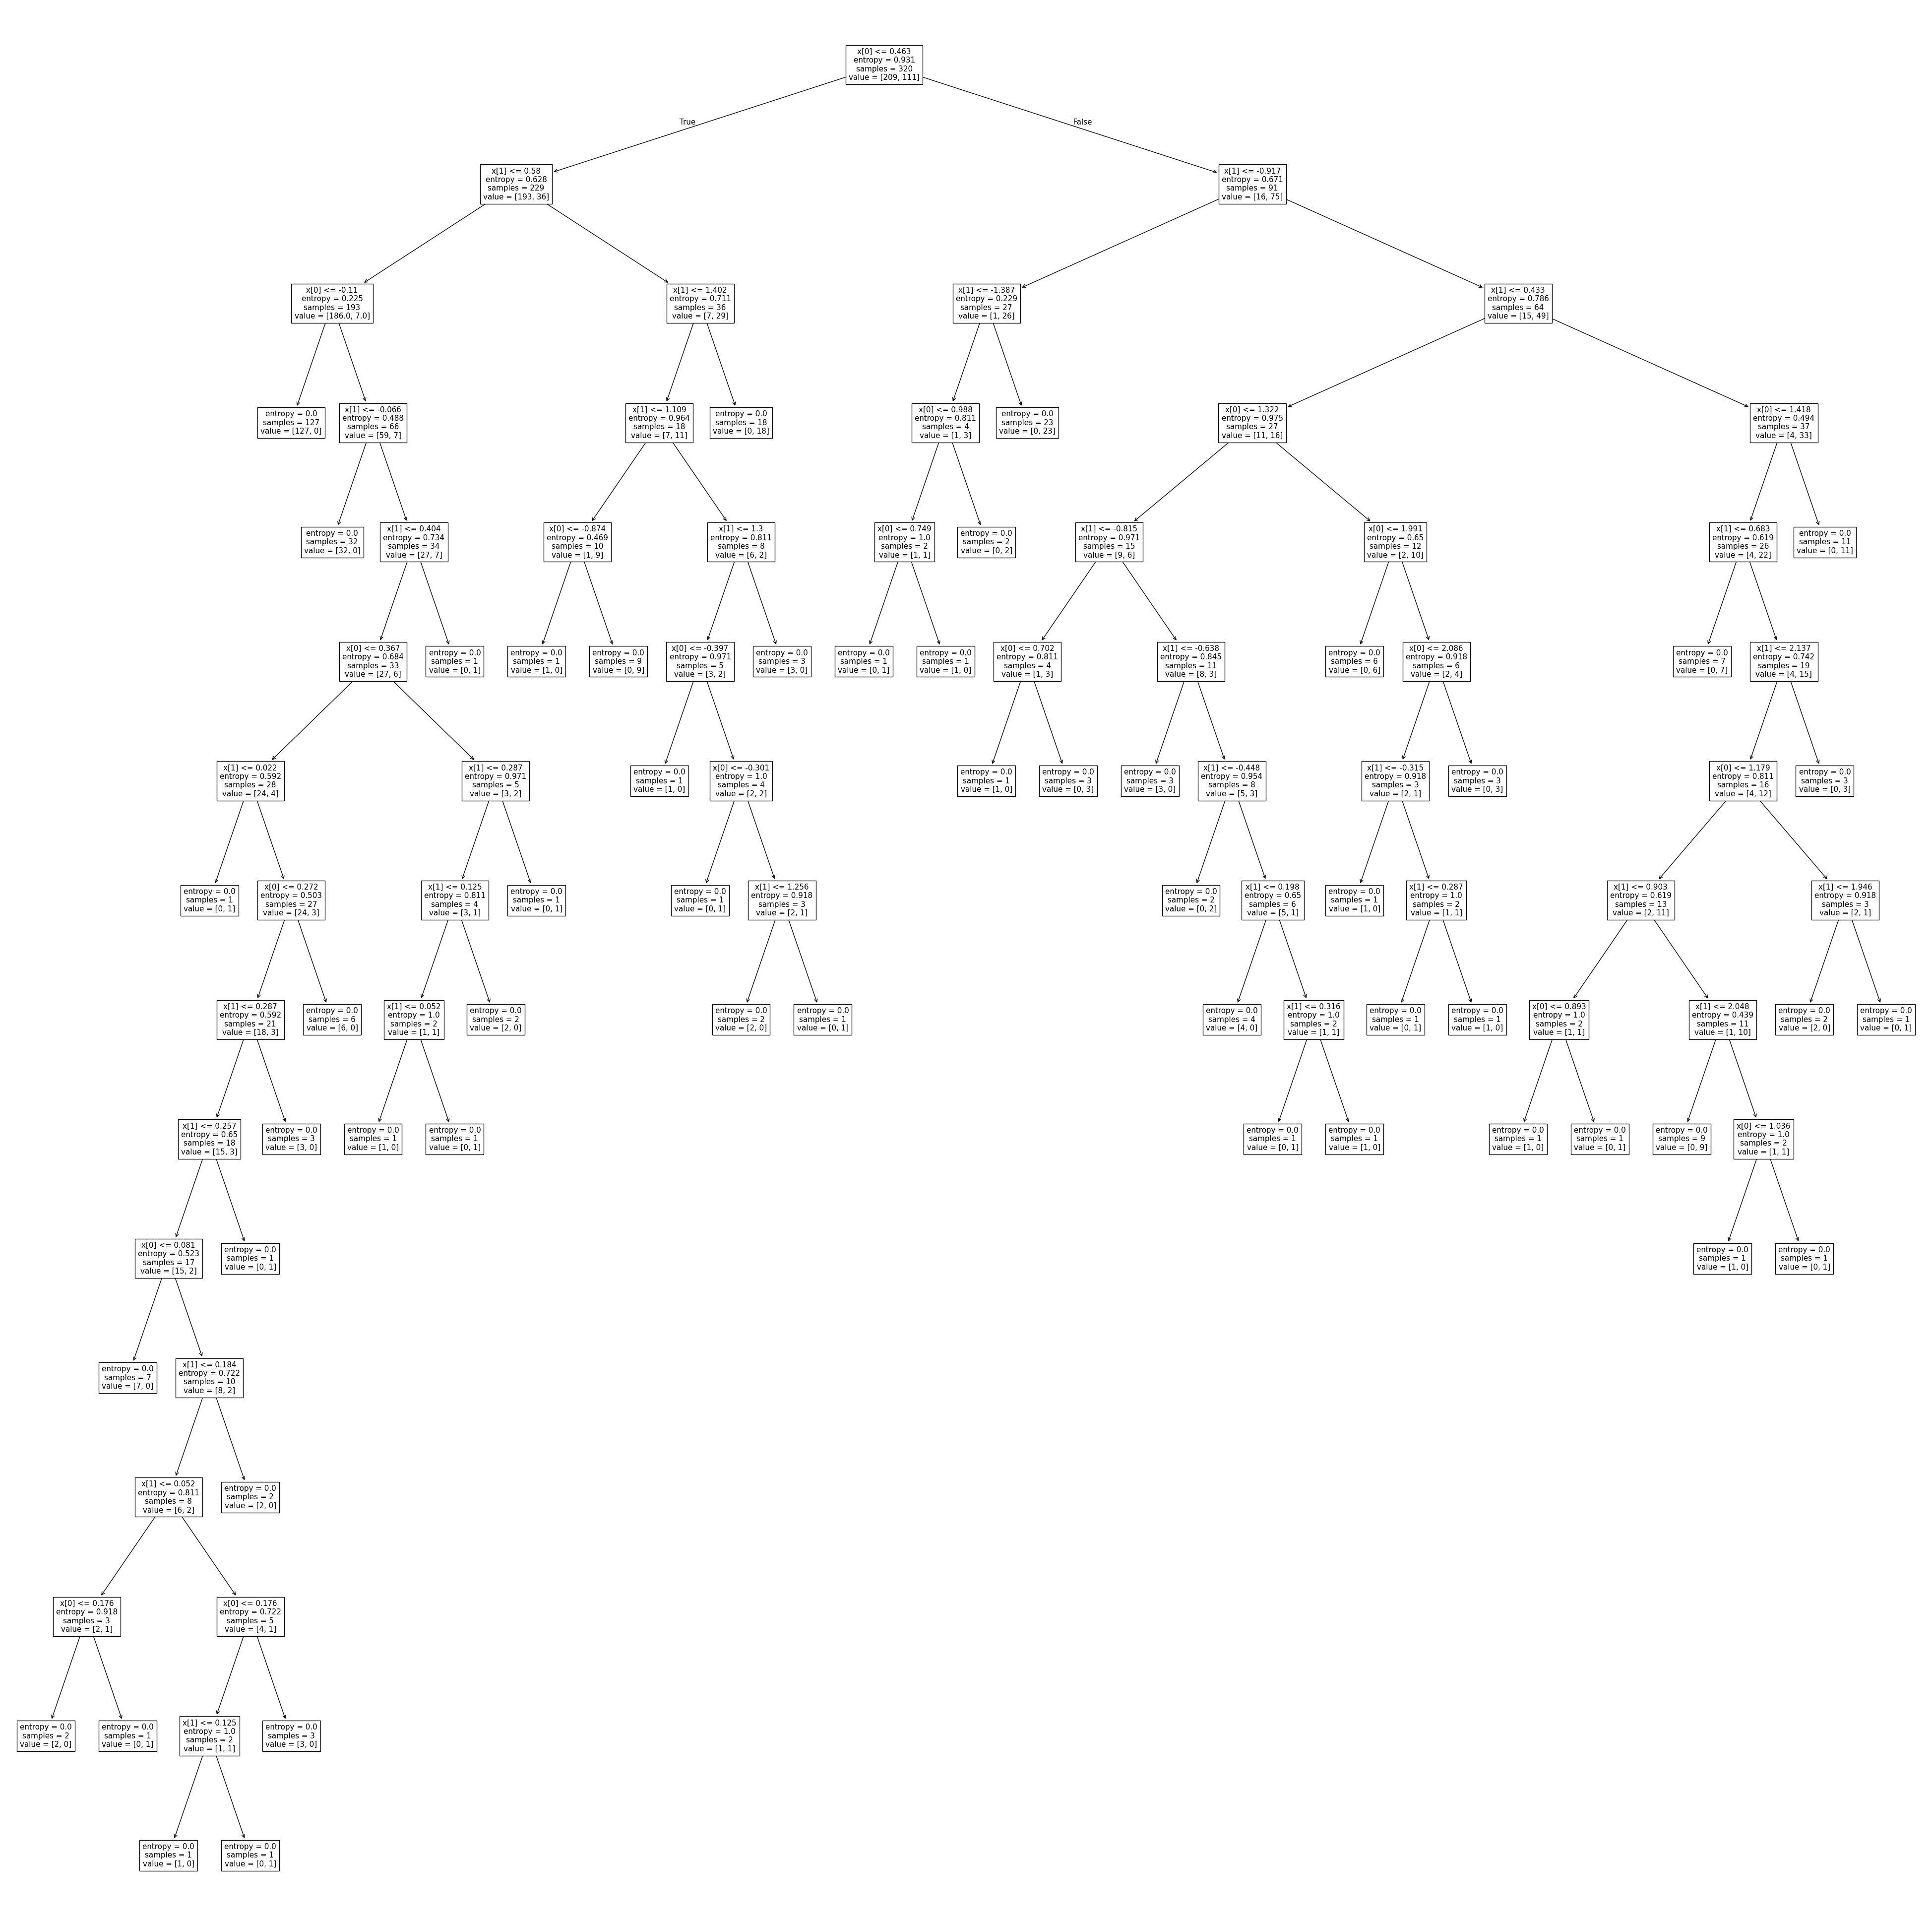

In [25]:
plt.figure(figsize=(50,50))
plot_tree(dtce)
# plt.savefig("demo.jpg")
plt.show()

In [27]:
# if model is overfitted then perform PRUNING.
# to check overfitting model by comparing the training and testing accuracy. if there is difference between training and testing
# data then the model is overfitted.

In [28]:
dtc.score(x_train, y_train) * 100

100.0

# Pre-Pruning

In [31]:
# To use pre-Pruning we can add max_depth value to the DecisionTreeClassifier method
# like: DecisionTreeClassifier(max_depth=5)

In [32]:
pp_dtc = DecisionTreeClassifier(max_depth=5)

In [33]:
pp_dtc.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
pp_dtc.score(x_test, y_test) * 100, pp_dtc.score(x_train, y_train) * 100

(88.75, 94.0625)

In [35]:
# after pre-pruning the accuracy of the training and testing data has been increased.

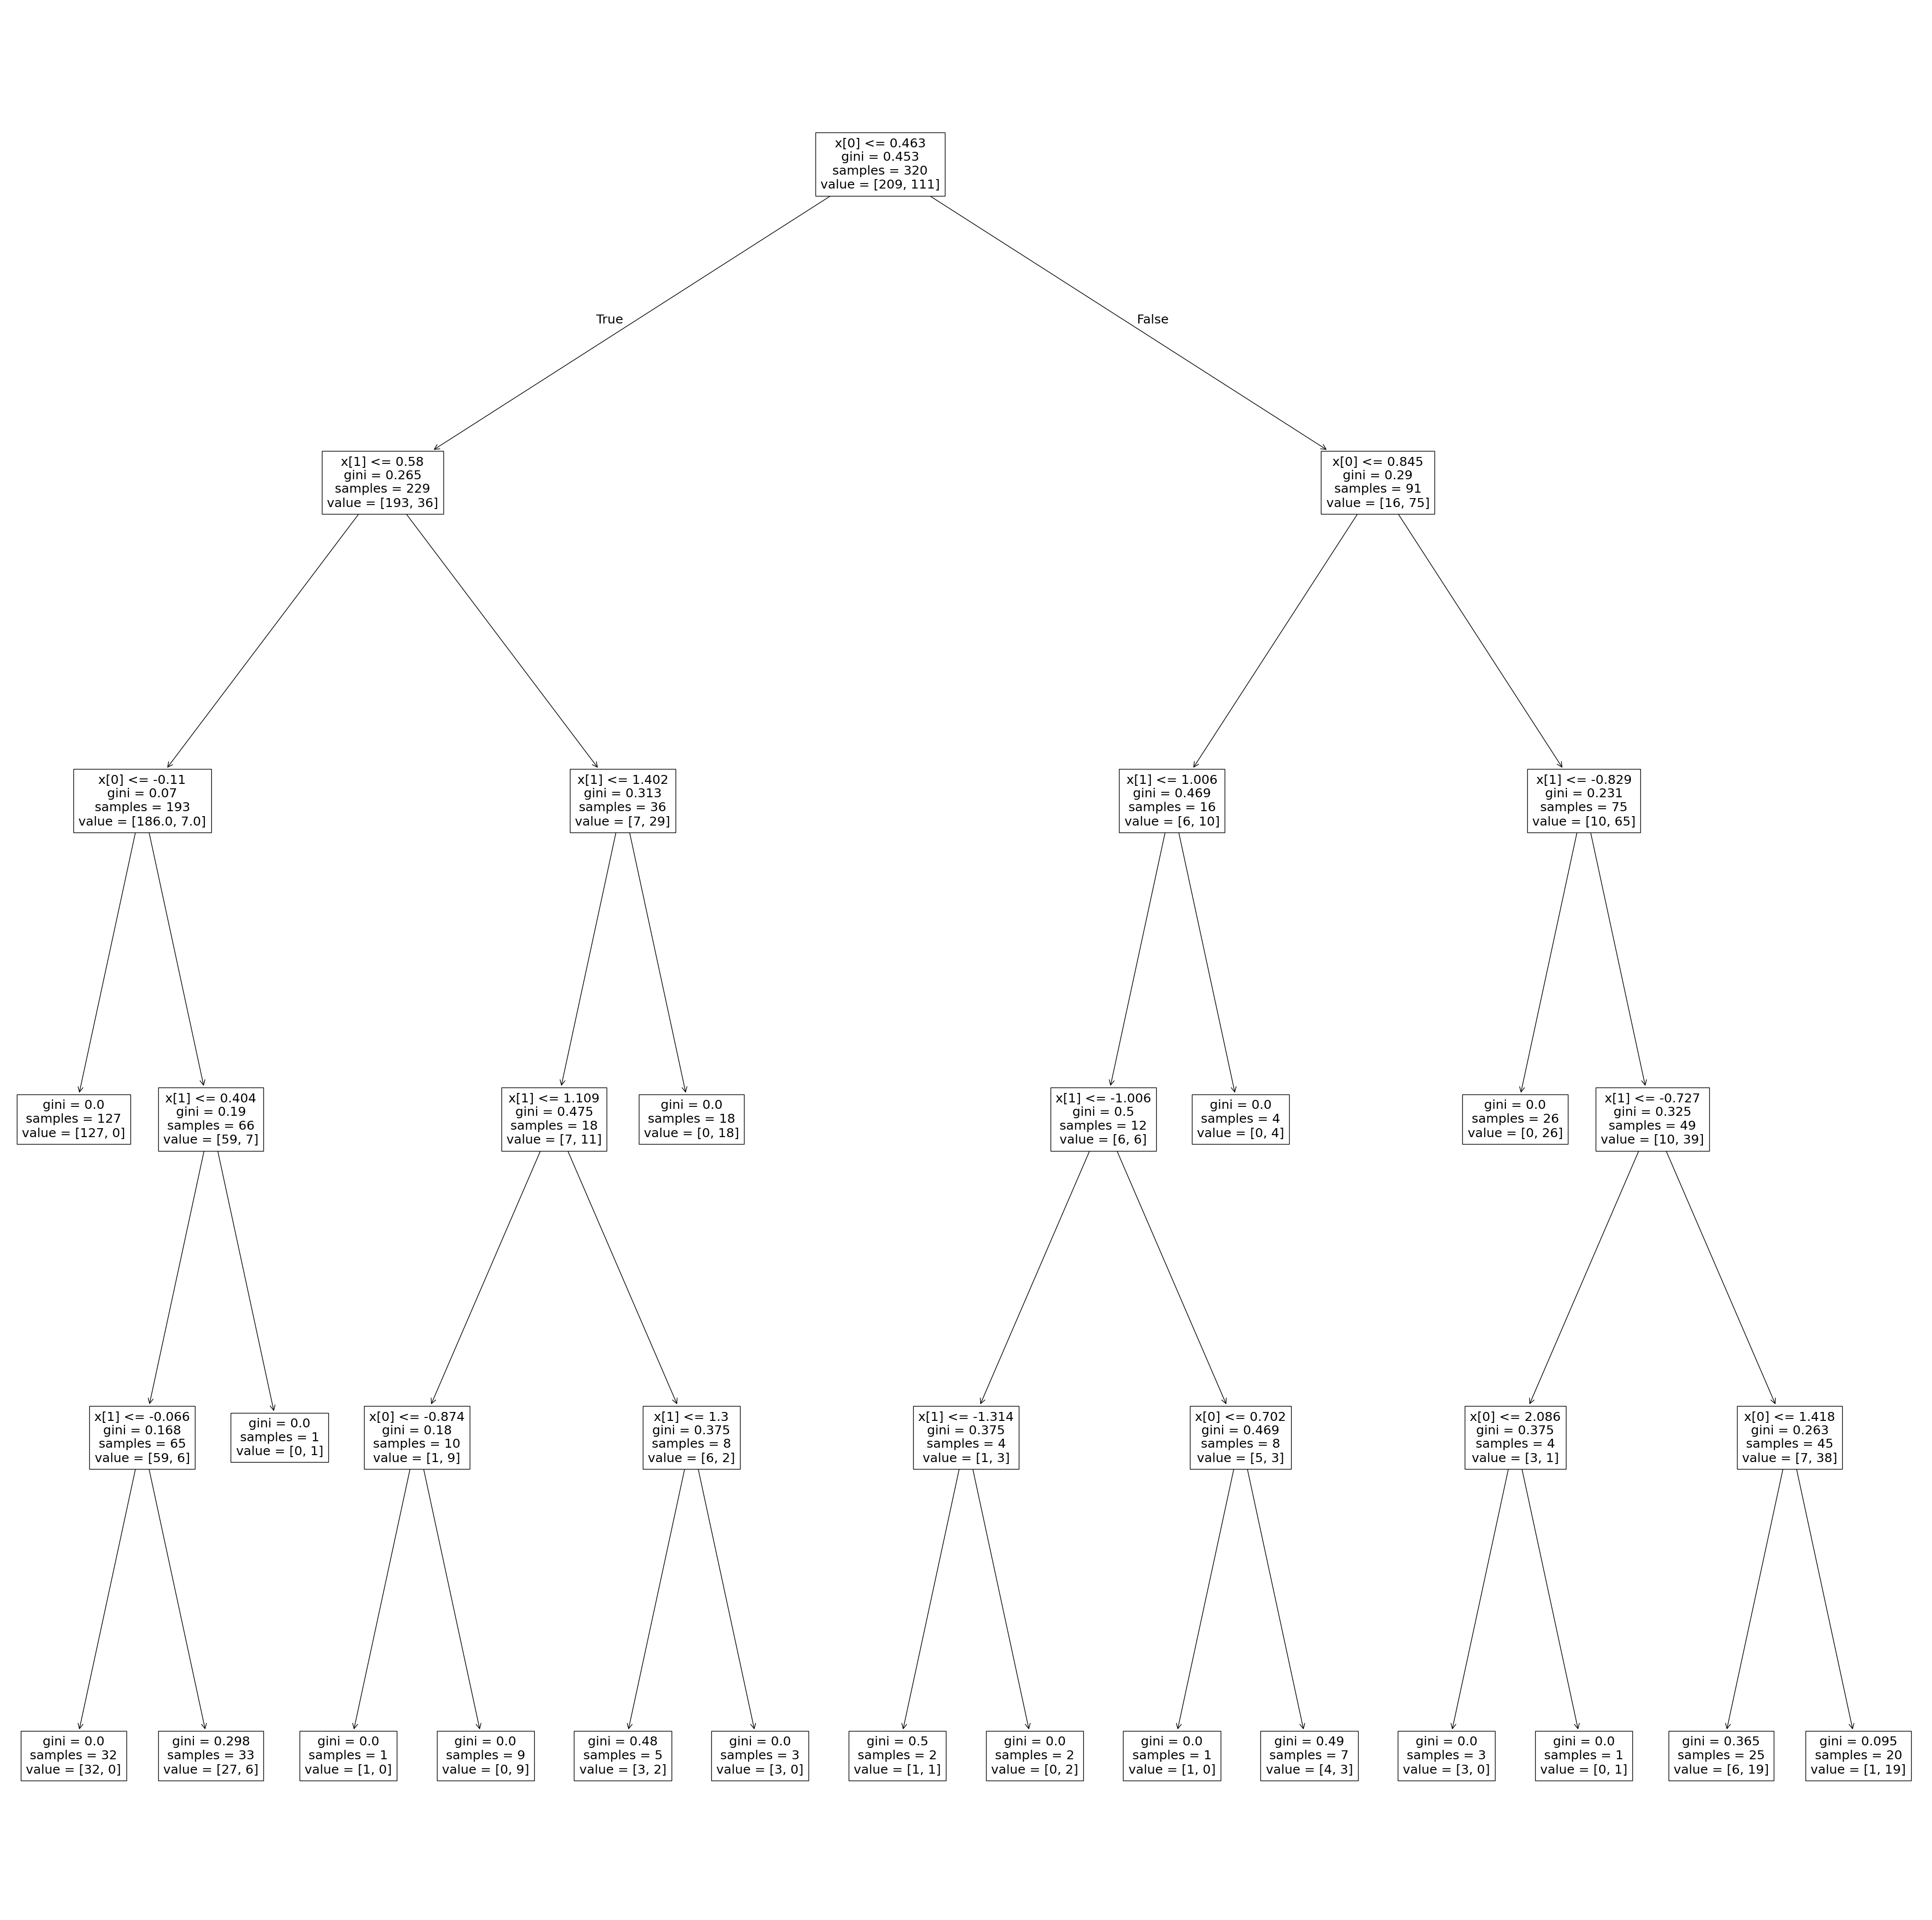

In [36]:
plt.figure(figsize=(50,50))
plot_tree(pp_dtc)
# plt.savefig("pre-pruning-image.jpg")
plt.show()

# Post-Pruning

In [38]:
for i in range(1, 20):
    post_dtc = DecisionTreeClassifier(max_depth=i)
    post_dtc.fit(x_train, y_train)
    train_score = post_dtc.score(x_train, y_train) * 100
    test_score = post_dtc.score(x_test, y_test) * 100
    print(f"max depth level: {i}, Train Accuracy: {train_score}, Test Accuracy: {test_score}")

max depth level: 1, Train Accuracy: 83.75, Test Accuracy: 85.0
max depth level: 2, Train Accuracy: 90.625, Test Accuracy: 93.75
max depth level: 3, Train Accuracy: 90.625, Test Accuracy: 88.75
max depth level: 4, Train Accuracy: 93.4375, Test Accuracy: 90.0
max depth level: 5, Train Accuracy: 94.0625, Test Accuracy: 88.75
max depth level: 6, Train Accuracy: 95.0, Test Accuracy: 87.5
max depth level: 7, Train Accuracy: 96.25, Test Accuracy: 88.75
max depth level: 8, Train Accuracy: 97.1875, Test Accuracy: 87.5
max depth level: 9, Train Accuracy: 98.125, Test Accuracy: 87.5
max depth level: 10, Train Accuracy: 98.75, Test Accuracy: 86.25
max depth level: 11, Train Accuracy: 99.0625, Test Accuracy: 86.25
max depth level: 12, Train Accuracy: 99.375, Test Accuracy: 86.25
max depth level: 13, Train Accuracy: 99.375, Test Accuracy: 85.0
max depth level: 14, Train Accuracy: 99.6875, Test Accuracy: 85.0
max depth level: 15, Train Accuracy: 100.0, Test Accuracy: 85.0
max depth level: 16, Train A